In [1]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
import pandas as pd
from pathlib import Path


%matplotlib inline 
import matplotlib.pyplot as plt
import seaborn as sns
import src.util_analysis as util_analysis

In [6]:
h5_dir = Path("binaural_unit_activation_analysis")
model = "word_task_v10_main_feature_gain_config"
h5_path = h5_dir / f"{model}/{model}_model_activations_0dB_diotic_cue_single_source.h5"

In [7]:
acts =  h5py.File(h5_path, 'r')
all_act_keys = list(acts.keys())
target_locs = acts['target_loc'][:]
acts.close()
# [key.split("_mixture")[0] for key in all_act_keys if ("mixture" in key) and (not any([str_part in key for str_part in ['f0', 'loc', 'word']]))]


In [9]:
h5_file = h5py.File(h5_path, 'r') 
layer_names = sorted(list(set([l.split('_target')[0] for l in all_act_keys if 'target' in l and not  any([str_part in l for str_part in ['_f0', '_loc', '_word']])]))) # set to remove duplicates 


In [10]:
sum_unit_acts = h5_file['hann_pool_1_target'][:].sum(0)

In [11]:
dead_units = np.where(sum_unit_acts == 0)[0]
len(dead_units)

1928

In [12]:
corr_dfs = []
# cos_dfs = []

# for path in paths:
distractor_conditions = ['same_sex_talker', 'diff_sex_talker', 'natural_scene']

# just look at 0,0 co-located examples 
wanted_rows = np.where(np.all(target_locs == [0,0], axis=1))[0]

with h5py.File(h5_path, 'r') as acts:
    ## Get keys with corr in them 
    layer_names = set([l.split('_target')[0] for l in all_act_keys if 'target' in l and not  any([str_part in l for str_part in ['_f0', '_loc', '_word']])]) # set to remove duplicates 
    print(layer_names)

    dfs = []
    for layer in layer_names:
        for dist_cond in distractor_conditions:
            data_dict = {}
            if dist_cond == 'same_sex_talker':
                fg_corr_key = f"{layer}_target_mixture_same_corr"
                bg_corr_key = f"{layer}_same_sex_dist_mixture_same_corr"
            elif dist_cond == 'diff_sex_talker':
                fg_corr_key = f"{layer}_target_mixture_diff_corr"
                bg_corr_key = f"{layer}_diff_sex_dist_mixture_diff_corr"
            elif dist_cond == 'natural_scene':
                fg_corr_key = f"{layer}_target_mixture_nat_scene_corr"
                bg_corr_key = f"{layer}_nat_scene_dist_mixture_nat_scene_corr"   
            if layer == 'cochleagram':
                bg_corr_key = bg_corr_key.replace('sex_', '')      

            N_examples = len(wanted_rows)
            data_dict['fg_corrs'] = acts[fg_corr_key][wanted_rows,0]
            data_dict['bg_corrs'] = acts[bg_corr_key][wanted_rows,0]

            data_dict['layer'] = [layer] * N_examples
            data_dict['distractor_condition'] = [dist_cond] * N_examples

            df = pd.DataFrame(data_dict)
            df['model_name'] = util_analysis.model_name_dict[h5_path.parent.name]
            dfs.append(df)
act_results  = pd.concat(dfs, ignore_index=True)

act_results['layer'] = act_results['layer'].str.replace('_block_', '')

act_results['log_corr_ratio'] = np.log(np.sqrt(act_results['fg_corrs']**2 / act_results['bg_corrs']**2))

act_corrs = pd.melt(act_results[[col for col in act_results.columns if 'cos' not in col]], id_vars =['layer', 'distractor_condition', 'model_name'], value_vars=['fg_corrs', 'bg_corrs'], var_name='Stream',
                            value_name="Pearson's r")


act_corrs['Stream'].replace('fg_corrs','corr(target$_i$, mixture$_i$)',inplace=True)
act_corrs['Stream'].replace('bg_corrs','corr(distractor$_i$, mixture$_i$)',inplace=True)

act_corrs['distractor_condition'].replace('same_sex_talker','Same sex',inplace=True)
act_corrs['distractor_condition'].replace('diff_sex_talker','Different sex',inplace=True)
act_corrs['distractor_condition'].replace('natural_scene','Natural scene',inplace=True)

# same as above but cos instead of corrs 

# act_corrs['layer'].replace('cochleagram','cochlea',inplace=True)



{'hann_pool_3', 'hann_pool_1', 'conv_block_0_ln', 'conv_block_2_ln', 'conv_block_3_ln', 'conv_block_3_relu', 'hann_pool_5', 'conv_block_0_relu', 'attn6', 'conv_block_2_relu', 'conv_block_6_ln', 'cochleagram', 'hann_pool_2', 'hann_pool_4', 'attn5', 'relufc', 'norm_coch_rep', 'attn2', 'hann_pool_0', 'attn4', 'conv_block_4_ln', 'hann_pool_6', 'conv_block_5_ln', 'conv_block_1_relu', 'attnfc', 'conv_block_1_ln', 'conv_block_5_relu', 'conv_block_6_relu', 'attn0', 'conv_block_4_relu', 'attn3', 'attn1'}


/tmp/ipykernel_372845/3022617752.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  act_corrs['Stream'].replace('fg_corrs','corr(target$_i$, mixture$_i$)',inplace=True)
/tmp/ipykernel_372845/3022617752.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing '

In [13]:
act_corrs

,layer,distractor_condition,model_name,Stream,Pearson's r
0,hann_pool_3,Same sex,Feature-gain v10,"corr(target$_i$, mixture$_i$)",0.835019
1,hann_pool_3,Same sex,Feature-gain v10,"corr(target$_i$, mixture$_i$)",0.772120
2,hann_pool_3,Same sex,Feature-gain v10,"corr(target$_i$, mixture$_i$)",0.763350
3,hann_pool_3,Same sex,Feature-gain v10,"corr(target$_i$, mixture$_i$)",0.790783
4,hann_pool_3,Same sex,Feature-gain v10,"corr(target$_i$, mixture$_i$)",0.792473
...,...,...,...,...,...
19195,attn1,Natural scene,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.898232
19196,attn1,Natural scene,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.922134
19197,attn1,Natural scene,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.891034
19198,attn1,Natural scene,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.879061


In [14]:
layer_order = ['cochleagram',
                'norm_coch_rep',
                'attn0',
                'conv0_ln',
                'conv0_relu',
                'hann_pool_0',
                'attn1',
                'conv1_ln',
                'conv1_relu',
                'hann_pool_1',
                'attn2',
                'conv2_ln',
                'conv2_relu',
                'hann_pool_2',
                'attn3',
                'conv3_ln',
                'conv3_relu',
                'hann_pool_3',
                'attn4',
                'conv4_ln',
                'conv4_relu',
                'hann_pool_4',
                'attn5',
                'conv5_ln',
                'conv5_relu',
                'hann_pool_5',
                'attn6',
                'conv6_ln',
                'conv6_relu',
                'hann_pool_6',
                'attnfc',
                'relufc']

In [15]:
to_plot = act_corrs.set_index('layer')
to_plot = to_plot.loc[layer_order].reset_index()
to_plot

,layer,distractor_condition,model_name,Stream,Pearson's r
0,cochleagram,Same sex,Feature-gain v10,"corr(target$_i$, mixture$_i$)",0.716652
1,cochleagram,Same sex,Feature-gain v10,"corr(target$_i$, mixture$_i$)",0.638540
2,cochleagram,Same sex,Feature-gain v10,"corr(target$_i$, mixture$_i$)",0.695381
3,cochleagram,Same sex,Feature-gain v10,"corr(target$_i$, mixture$_i$)",0.713906
4,cochleagram,Same sex,Feature-gain v10,"corr(target$_i$, mixture$_i$)",0.660933
...,...,...,...,...,...
19195,relufc,Natural scene,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.226980
19196,relufc,Natural scene,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.081276
19197,relufc,Natural scene,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.161346
19198,relufc,Natural scene,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.175210


In [16]:
to_plot.groupby(['distractor_condition', 'layer', 'Stream'])["Pearson's r"].count()

distractor_condition  layer          Stream                           
Different sex         attn0          corr(distractor$_i$, mixture$_i$)    100
                                     corr(target$_i$, mixture$_i$)        100
                      attn1          corr(distractor$_i$, mixture$_i$)    100
                                     corr(target$_i$, mixture$_i$)        100
                      attn2          corr(distractor$_i$, mixture$_i$)    100
                                                                         ... 
Same sex              hann_pool_6    corr(target$_i$, mixture$_i$)        100
                      norm_coch_rep  corr(distractor$_i$, mixture$_i$)    100
                                     corr(target$_i$, mixture$_i$)        100
                      relufc         corr(distractor$_i$, mixture$_i$)    100
                                     corr(target$_i$, mixture$_i$)        100
Name: Pearson's r, Length: 192, dtype: int64

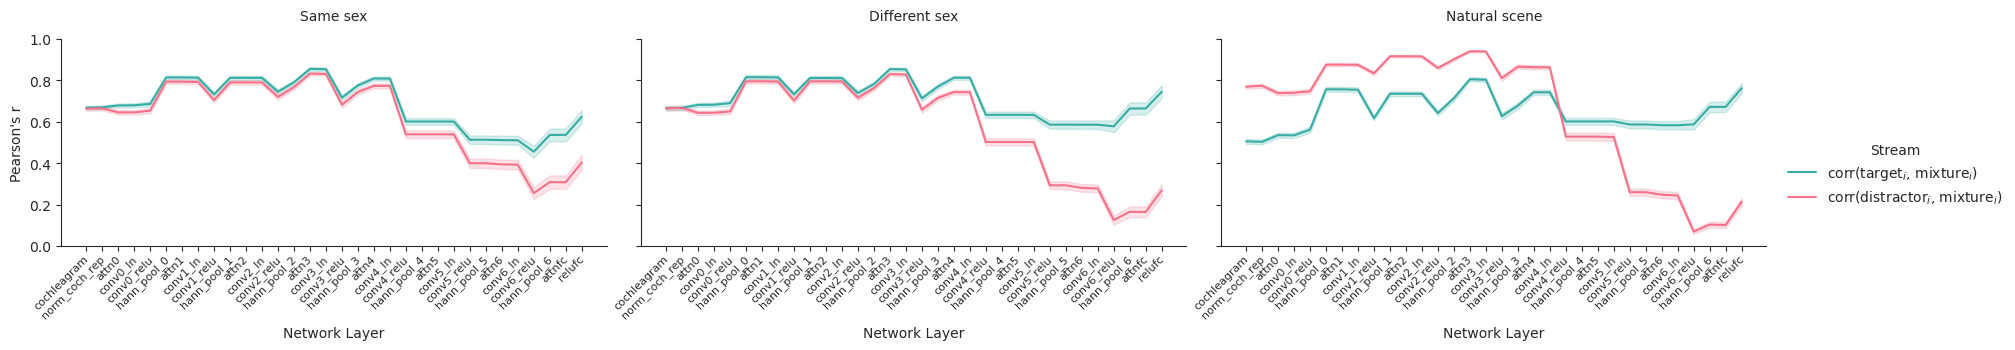

In [17]:
## Plot summary_results df 
sns.set_style('ticks')
# order = np.sort(results.layer.unique())

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)'] 
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[1],
                'corr(distractor$_i$, mixture$_i$)': palette[0],}

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-'}  

p = sns.relplot(kind='line', 
                data=to_plot, 
                # order=layer_order,
                x='layer',
                y="Pearson's r", #order=order,
                col = 'distractor_condition', 
                hue = 'Stream',
                hue_order = hue_order,
                palette=palette_dict, 
                height=3, aspect=2, 
                sort=False,
            #   err_style='bars', err_kws={'elinewidth': 1},
                errorbar=('se', 2), seed=1)

            #   errorbar=('ci'), n_boot=10_000, seed=1)

fontsize=10
tick_fontsize = 8

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
p.set_titles("{col_name}", size=fontsize, y=1.05)
# p.axes[0,0].xaxis.labelpad = -0.25
# set y limit to 0,1
p.set(ylim=(0,1))
# move x axis label up 

# p.set_
p.set_xticklabels(rotation=45, size=tick_fontsize,  ha='right', va='center_baseline',  rotation_mode='anchor')
    


Text(0.5, 1.1, 'Stage of selection by distractor type')

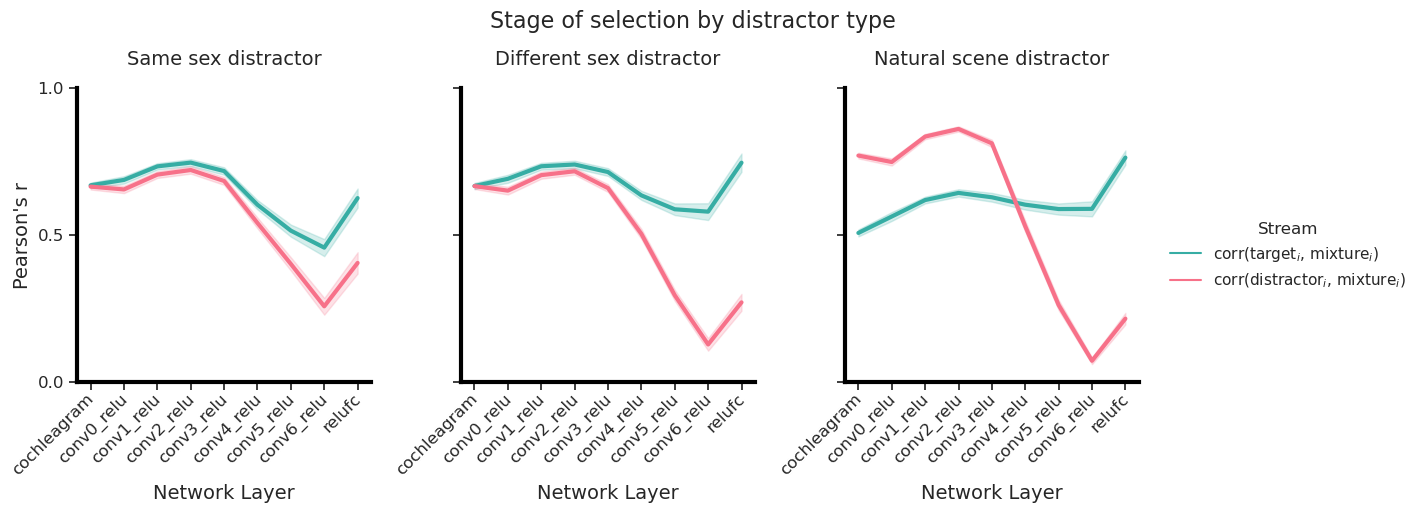

In [18]:
### Plot cochleagram and activation layers only 
layers_to_plot = ['cochleagram'] + [layer for layer in layer_order if 'relu' in layer]


## Plot summary_results df 
sns.set_context('notebook')
# order = np.sort(results.layer.unique())
# plt.rc('font', family='Helvetica')

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)'] 
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[1],
                'corr(distractor$_i$, mixture$_i$)': palette[0],}

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-'}  

p = sns.relplot(kind='line', 
                data=to_plot[to_plot.layer.isin(layers_to_plot)], 
                # order=layer_order,
                x='layer',
                y="Pearson's r", #order=order,
                col = 'distractor_condition', 
                hue = 'Stream',
                hue_order = hue_order,
                palette=palette_dict, 
                height=4, #aspect=2, 
                sort=False,
            #   err_style='bars', err_kws={'elinewidth': 1},
                errorbar=('se', 2), seed=1)

            #   errorbar=('ci'), n_boot=10_000, seed=1)

fontsize=14
tick_fontsize = 12

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
p.set_titles("{col_name} distractor", size=fontsize, y=1.05)
# p.axes[0,0].xaxis.labelpad = -0.25
# set y limit to 0,1
p.set(ylim=(0,1))
# move x axis label up 

# p.set_
p.set_xticklabels(rotation=45, size=tick_fontsize,  ha='right', va='center_baseline',  rotation_mode='anchor')
    
# set first row x and y limits to 0 1
yticks = np.linspace(0,1,3).round(1)
ratio = 1.0

# increase axis thickness and set to square aspect

line_thickness = 3

for ax in p.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    ax.set_yticks(ticks=yticks) # set new labels
    ax.set_yticklabels(labels= yticks, fontsize=tick_fontsize)
    for line in ax.get_lines():
        line.set_linewidth(line_thickness)
        line.set_linestyle('-')
        line.set_alpha(1)
        # remove marker 

    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# replace legend with text of stream names 
# p._legend.remove()
plt.suptitle("Stage of selection by distractor type", y=1.1, fontsize=fontsize+2)
# # add text 
# p.fig.text(0.305, 0.9, 'corr(target$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['corr(target$_i$, mixture$_i$)'], ha='left');
# p.fig.text(0.305, 0.825, 'corr(distractor$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['corr(distractor$_i$, mixture$_i$)'], ha='left');

# plt.savefig(outfig_dest/'stage_of_selection_for_poster.pdf', transparent=True, bbox_inches='tight')



In [11]:
act_results

,fg_corrs,bg_corrs,layer,distractor_condition,model_name,log_corr_ratio
0,0.480254,0.281977,conv5_relu,same_sex_talker,Feature-gain v10,0.532491
1,0.543816,0.251140,conv5_relu,same_sex_talker,Feature-gain v10,0.772601
2,0.404224,0.412047,conv5_relu,same_sex_talker,Feature-gain v10,-0.019168
3,0.471341,0.408562,conv5_relu,same_sex_talker,Feature-gain v10,0.142938
4,0.483527,0.348386,conv5_relu,same_sex_talker,Feature-gain v10,0.327794
...,...,...,...,...,...,...
9595,0.422321,0.224461,attn6,natural_scene,Feature-gain v10,0.632067
9596,0.561855,0.137997,attn6,natural_scene,Feature-gain v10,1.404016
9597,0.368746,0.196471,attn6,natural_scene,Feature-gain v10,0.629594
9598,0.376619,0.193195,attn6,natural_scene,Feature-gain v10,0.667537


Text(0.5, 1.1, 'Stage of selection by distractor type')

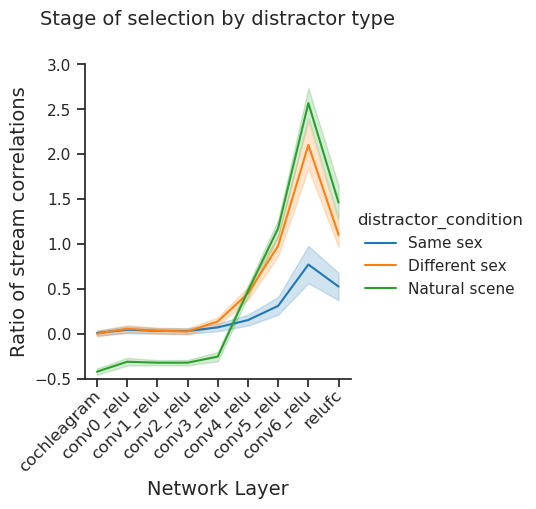

In [13]:
### Plot cochleagram and activation layers only 
layers_to_plot = ['cochleagram'] + [layer for layer in layer_order if 'relu' in layer]

to_plot = act_results.set_index('layer')
to_plot = to_plot.loc[layer_order].reset_index()

to_plot['distractor_condition'].replace('same_sex_talker','Same sex',inplace=True)
to_plot['distractor_condition'].replace('diff_sex_talker','Different sex',inplace=True)
to_plot['distractor_condition'].replace('natural_scene','Natural scene',inplace=True)


## Plot summary_results df 
sns.set_context('notebook')
# order = np.sort(results.layer.unique())
# plt.rc('font', family='Helvetica')

p = sns.relplot(kind='line', 
                data=to_plot[to_plot.layer.isin(layers_to_plot)], 
                # order=layer_order,
                x='layer',
                y="log_corr_ratio", #order=order,
                hue = 'distractor_condition', 
                height=4, #aspect=2, 
                sort=False,
            #   err_style='bars', err_kws={'elinewidth': 1},
                errorbar=('se', 2), seed=1)

            #   errorbar=('ci'), n_boot=10_000, seed=1)

fontsize=14
tick_fontsize = 12

p.set_axis_labels("Network Layer", "Ratio of stream correlations", size=fontsize)

# set y limit to 0,1
p.set(ylim=(-0.5, 3))
# move x axis label up 

# p.set_
p.set_xticklabels(rotation=45, size=tick_fontsize,  ha='right', va='center_baseline',  rotation_mode='anchor')
    
# set first row x and y limits to 0 1
# yticks = np.linspace(-2,2,5).round(1)
ratio = 1.0

# increase axis thickness and set to square aspect

line_thickness = 1.5
plt.title("Stage of selection by distractor type", y=1.1, fontsize=fontsize)
